# 05 – Conclude & Evaluate

**Projekt:** WealthScope AI 1.0
**Methode:** QUA³CK · reproduzierbarer Out-of-Time-Benchmark
**Hinweis:** Wissenschaftlicher Prototyp, keine Anlageberatung.

## Ergebnislogik

Accuracy allein ist wegen der Mehrheitsklasse irreführend. Deshalb werden
Balanced Accuracy, ROC-AUC, Average Precision, Konfusionsmatrix und
Walk-forward-Stabilität gemeinsam bewertet.

## Lernziele

Nach diesem Notebook könnt ihr:

- eine Punktschätzung durch ein Konfidenzintervall ergänzen
- statistische Signifikanz von praktischer Bedeutung trennen
- ein Negativergebnis gegen seine Gegenerklärungen absichern
- die Grenzen der eigenen Arbeit präzise statt pauschal benennen

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "wealthscope_features.parquet"
DIAGNOSTICS_PATH = PROJECT_ROOT / "models" / "diagnostics.json"
EXPERIMENTS_PATH = PROJECT_ROOT / "models" / "validation_experiments.json"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Datensatz fehlt: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"Daten: {len(df):,} Zeilen × {len(df.columns)} Spalten")
display(df.head(3))

Daten: 192,119 Zeilen × 27 Spalten


,date,open,high,low,close,volume,ticker,asset_type,source_file,daily_return,...,ma_200_distance,volatility_20d,rolling_high,drawdown,future_return_20d,target_20d,open_interest,volatility_60d,rolling_low_60,rolling_high_60
0,1985-06-21,0.25742,0.26381,0.25742,0.25742,46333854,AAPL,Stock,Stocks/aapl.us.txt,0.020374,...,-0.331288,0.040521,0.48791,-0.472403,0.044635,1.0,NaN,NaN,NaN,NaN
1,1985-06-24,0.27535,0.27920,0.27535,0.27535,57384755,AAPL,Stock,Stocks/aapl.us.txt,0.069653,...,-0.283328,0.040440,0.48791,-0.435654,-0.041910,0.0,NaN,NaN,NaN,NaN
2,1985-06-25,0.27920,0.28556,0.27920,0.27920,81966629,AAPL,Stock,Stocks/aapl.us.txt,0.013982,...,-0.271961,0.037120,0.48791,-0.427763,-0.073424,0.0,NaN,NaN,NaN,NaN


In [2]:
diagnostics = json.loads(DIAGNOSTICS_PATH.read_text(encoding="utf-8"))
m = diagnostics["test_metrics"]
summary = pd.Series({
    "Random-Forest Accuracy": m["accuracy"],
    "Mehrheitsbaseline Accuracy": m["majority_baseline"],
    "Balanced Accuracy": m["balanced_accuracy"],
    "ROC-AUC": m["roc_auc"],
    "Average Precision": m["average_precision"],
    "Walk-forward ROC-AUC": diagnostics["cross_validation"]["auc_mean"],
})
summary.to_frame("Wert").style.format("{:.3f}")

,Wert
Random-Forest Accuracy,0.519
Mehrheitsbaseline Accuracy,0.591
Balanced Accuracy,0.513
ROC-AUC,0.519
Average Precision,0.611
Walk-forward ROC-AUC,0.514


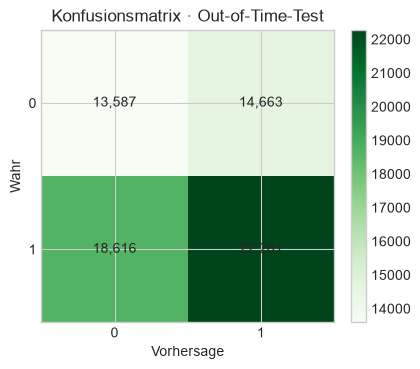

In [3]:
cm = np.array(diagnostics["confusion_matrix"]["counts"])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(cm, cmap="Greens")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f"{value:,}", ha="center", va="center")
ax.set_xticks([0, 1], ["0", "1"])
ax.set_yticks([0, 1], ["0", "1"])
ax.set_xlabel("Vorhersage")
ax.set_ylabel("Wahr")
ax.set_title("Konfusionsmatrix · Out-of-Time-Test")
plt.colorbar(im, ax=ax, fraction=.045)
plt.show()

In [4]:
hypotheses = pd.DataFrame([
    ["H1", "falsifiziert",
     f"RF AUC {m['roc_auc']:.3f}; Walk-forward {diagnostics['cross_validation']['auc_mean']:.3f}"],
    ["H2", "im Prototyp umgesetzt", "App, Methodik, Export und Lernstudio; Nutzerstudie offen"],
    ["H3", "teilweise plausibel", "Orientierung verbessert; wirtschaftlicher Nutzen nicht bewiesen"],
], columns=["Hypothese", "Urteil", "Begründung"])
hypotheses

,Hypothese,Urteil,Begründung
0,H1,falsifiziert,RF AUC 0.519; Walk-forward 0.514
1,H2,im Prototyp umgesetzt,"App, Methodik, Export und Lernstudio; Nutzerst..."
2,H3,teilweise plausibel,Orientierung verbessert; wirtschaftlicher Nutz...


H1 ist **falsifiziert, nicht ungeprüft**. Die Hypothese war so formuliert, dass
sie scheitern konnte – genau das macht sie zu einer wissenschaftlichen Aussage.

## Wie sicher ist die 0,519 überhaupt?

Eine Punktschätzung ohne Streuungsmaß ist unvollständig. `0,519` könnte ein
stabiler kleiner Vorsprung sein — oder Zufall. Ein **Bootstrap** beantwortet
das: Aus dem Testfenster werden wiederholt Stichproben mit Zurücklegen gezogen
und jedes Mal die AUC neu berechnet. Die Streuung dieser Werte schätzt die
Unsicherheit der Kennzahl.

In [5]:
import joblib
from sklearn.metrics import roc_auc_score

features = diagnostics["features"]
V = diagnostics["validation"]

modelldaten = df.dropna(subset=features + ["target_20d", "date"]).sort_values(["date", "ticker"])
test = modelldaten[modelldaten["date"] >= pd.Timestamp(V["test_start"])]

modell = joblib.load(PROJECT_ROOT / "models" / "wealthscope_model.joblib")
p = modell.predict_proba(test[features])[:, 1]
y = test["target_20d"].astype(int).to_numpy()

auc_punkt = roc_auc_score(y, p)
print(f"AUC aus dem Artefakt : {m['roc_auc']:.6f}")
print(f"AUC hier reproduziert: {auc_punkt:.6f}")

rng = np.random.default_rng(42)
B, n = 400, len(y)
werte = []
for _ in range(B):
    idx = rng.integers(0, n, n)
    if y[idx].min() == y[idx].max():
        continue
    werte.append(roc_auc_score(y[idx], p[idx]))
werte = np.array(werte)
lo, hi = np.percentile(werte, [2.5, 97.5])

print(f"\nBootstrap mit B={len(werte)} Ziehungen über {n:,} Testfälle")
print(f"95 %-Konfidenzintervall: [{lo:.4f}, {hi:.4f}]")
print(f"Anteil der Ziehungen mit AUC <= 0,5: {(werte <= 0.5).mean():.4f}")

AUC aus dem Artefakt : 0.519185
AUC hier reproduziert: 0.519185



Bootstrap mit B=400 Ziehungen über 69,147 Testfälle
95 %-Konfidenzintervall: [0.5146, 0.5233]
Anteil der Ziehungen mit AUC <= 0,5: 0.0000


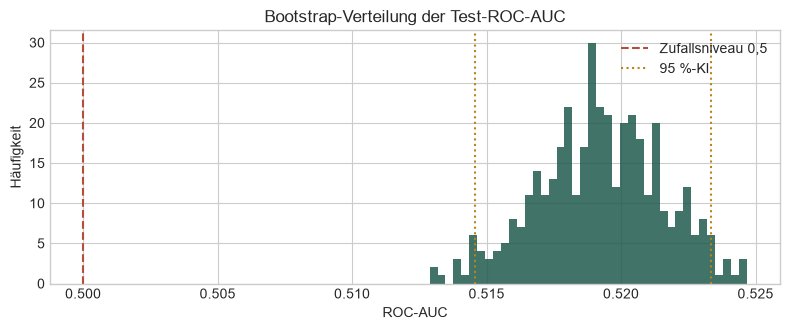

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(werte, bins=40, color="#1F5A4E", alpha=.85)
ax.axvline(0.5, color="#B54D3A", linestyle="--", linewidth=1.5, label="Zufallsniveau 0,5")
ax.axvline(lo, color="#B98519", linestyle=":", linewidth=1.5, label="95 %-KI")
ax.axvline(hi, color="#B98519", linestyle=":", linewidth=1.5)
ax.set_title("Bootstrap-Verteilung der Test-ROC-AUC")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Häufigkeit")
ax.legend()
plt.tight_layout()
plt.show()

### Signifikant ja, bedeutsam nein

Das Konfidenzintervall liegt bei etwa **[0,515; 0,523]** und schließt das
Zufallsniveau 0,5 aus. Statistisch ist der Vorsprung also **nachweisbar** — bei
69.147 Testfällen wird auch ein winziger Effekt signifikant.

Genau hier liegt die Falle, vor der Notebook 01 gewarnt hat. Ein naives „AUC > 0,5,
also H1 bestätigt" wäre formal vertretbar und inhaltlich falsch. Denn:

- Der Vorsprung beträgt rund **2 AUC-Punkte** gegenüber Münzwurf.
- Er ist über die Walk-forward-Folds **nicht stabil** (0,514 im Mittel, eine
  Standardabweichung von 0,014 — einzelne Folds liegen unter 0,5).
- Er reicht nach Notebook 04 nicht für einen Precision-Vorsprung, der
  Transaktionskosten überstehen würde.

**Statistische Signifikanz ist nicht dasselbe wie praktische Bedeutung.** H1
verlangte einen Vorsprung, der *deutlich* und *stabil* ist. Beides ist nicht
erfüllt — deshalb gilt die Hypothese als falsifiziert, obwohl das Intervall die
0,5 ausschließt. Diese Unterscheidung sauber zu treffen, ist das eigentliche
Ergebnis der Evaluationsphase.

Ein Negativergebnis ist allerdings nur dann ein Befund, wenn die naheliegenden
Gegenerklärungen ausgeschlossen sind. Genau das prüft die nächste Zelle.

In [7]:
experiments = json.loads(EXPERIMENTS_PATH.read_text(encoding="utf-8"))
cap = experiments["capacity_sweep_summary"]
split = experiments["split_comparison_summary"]
lc = json.loads((PROJECT_ROOT / "models" / "learning_curve.json").read_text(encoding="utf-8"))
val_trend = lc["val_scores_mean"][-1] - lc["val_scores_mean"][0]
data_factor = lc["train_sizes_abs"][-1] / lc["train_sizes_abs"][0]

checks = pd.DataFrame([
    ["Zu wenig Modellkapazität?", "ausgeschlossen",
     f"Test-AUC-Spanne über 7 Stufen nur {cap['test_roc_auc_span']:.4f} "
     f"({cap['test_roc_auc_min']:.4f}–{cap['test_roc_auc_max']:.4f})"],
    ["Zu wenig Daten?", "ausgeschlossen",
     f"{data_factor:.1f}-fache Trainingsmenge verändert die Validierung um "
     f"{val_trend:+.4f}"],
    ["Ist die Aufteilung der Hebel?", "ja – und zwar der einzige",
     f"naiver Zufalls-Split: AUC {split['leaky_roc_auc']:.4f} statt "
     f"{split['reference_roc_auc']:.4f} → scheinbares Signal "
     f"{split['apparent_signal_factor']:.1f}x größer"],
], columns=["Gegenerklärung", "Ergebnis", "Belegte Messung"])
checks.style.hide(axis="index")

Gegenerklärung,Ergebnis,Belegte Messung
Zu wenig Modellkapazität?,ausgeschlossen,Test-AUC-Spanne über 7 Stufen nur 0.0071 (0.5121–0.5192)
Zu wenig Daten?,ausgeschlossen,2.3-fache Trainingsmenge verändert die Validierung um -0.0047
Ist die Aufteilung der Hebel?,ja – und zwar der einzige,naiver Zufalls-Split: AUC 0.5813 statt 0.5192 → scheinbares Signal 4.2x größer


## Fazit

Die Out-of-Time-AUC des Random Forest beträgt rund **0,519** – kein belastbares
Handelssignal. Das eigentliche Ergebnis dieses Projekts ist deshalb nicht das
Modell, sondern eine **Messung**: Wie viel verwertbare Information tragen rein
kursbasierte technische Indikatoren? Antwort: nahezu keine, belegt an 190.527
Beobachtungen mit elf Jahren unangetastetem Testzeitraum.

Zwei Gegenerklärungen wurden ausgeschlossen (Kapazität, Datenmenge), und der
tatsächliche Hebel wurde beziffert: Ein naiver Zufalls-Split hätte dieselben
Daten mit AUC 0,581 bewertet – ein rund **4,2-mal größeres scheinbares Signal**.
Damit ist die niedrige Kennzahl kein Qualitätsmangel, sondern der Nachweis, dass
dieser Fehler nicht gemacht wurde. Das ist eine nachgerechnete, nicht bloß
zitierte Bestätigung der Effizienzmarkthypothese (Fama 1970).

### Nächste Schritte

- echter Forward-Test mit neueren Daten;
- Transaktionskosten, Slippage und Steuern;
- Makro-, Fundamental- und Sentimentvariablen (der einzige Hebel, der die
  Validierungskurve heben könnte);
- formale Nutzerstudie zur Verständlichkeit.

## Management-Checkpoint

**Entscheidungsvorlage in fünf Sätzen.**

Ein Modell auf rein kursbasierten technischen Indikatoren erreicht im ehrlichen
Out-of-Time-Test eine ROC-AUC von 0,519 mit einem 95 %-Konfidenzintervall von
etwa [0,515; 0,523]. Der Vorsprung vor dem Zufall ist damit statistisch
nachweisbar, aber zu klein und zeitlich zu instabil, um Transaktionskosten zu
überstehen — H1 ist falsifiziert. Die beiden naheliegenden Ausreden sind
ausgeschlossen: Weder mehr Modellkapazität (Test-AUC-Spanne 0,007 über sieben
Stufen) noch mehr Daten (−0,005 über die 2,3-fache Trainingsmenge) heben das
Ergebnis. Dass andere Arbeiten hier bessere Zahlen berichten, lässt sich
beziffern: Ein naiver Zufalls-Split hätte auf denselben Daten 0,581 ergeben, ein
4,2-mal größeres scheinbares Signal.

**Empfehlung:** Kein Einsatz als Signalgeber. Investition in exogene Datenquellen
statt in größere Modelle auf denselben Features. Der Wert dieser Arbeit liegt in
der Messmethodik, die jedes Folgeprojekt übernehmen sollte — insbesondere die
Regel, jedes Feature am Prognosezeitpunkt zu prüfen.